In [1]:
import kagglehub
erenaktas_human_activity_recognition_path = kagglehub.dataset_download('erenaktas/human-activity-recognition', force_download=True)
datadir = erenaktas_human_activity_recognition_path + "/UCI_HAR_Dataset"

100%|██████████| 119M/119M [00:18<00:00, 6.94MB/s] 

Extracting files...


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid") # https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html
sns.set_style("white") # https://seaborn.pydata.org/generated/seaborn.set_style.html
from mpl_toolkits import mplot3d
from mpl_toolkits.mplot3d import axes3d
import matplotlib as mpl

import os
for dirname, _, filenames in os.walk(datadir):
    for filename in filenames:
        print(os.path.join(dirname, filename))

C:\Users\Admin\.cache\kagglehub\datasets\erenaktas\human-activity-recognition\versions\1/UCI_HAR_Dataset\activity_labels.txt
C:\Users\Admin\.cache\kagglehub\datasets\erenaktas\human-activity-recognition\versions\1/UCI_HAR_Dataset\features.txt
C:\Users\Admin\.cache\kagglehub\datasets\erenaktas\human-activity-recognition\versions\1/UCI_HAR_Dataset\features_info.txt
C:\Users\Admin\.cache\kagglehub\datasets\erenaktas\human-activity-recognition\versions\1/UCI_HAR_Dataset\README.txt
C:\Users\Admin\.cache\kagglehub\datasets\erenaktas\human-activity-recognition\versions\1/UCI_HAR_Dataset\test\subject_test.txt
C:\Users\Admin\.cache\kagglehub\datasets\erenaktas\human-activity-recognition\versions\1/UCI_HAR_Dataset\test\X_test.txt
C:\Users\Admin\.cache\kagglehub\datasets\erenaktas\human-activity-recognition\versions\1/UCI_HAR_Dataset\test\y_test.txt
C:\Users\Admin\.cache\kagglehub\datasets\erenaktas\human-activity-recognition\versions\1/UCI_HAR_Dataset\test\Inertial Signals\body_acc_x_test.txt
C:

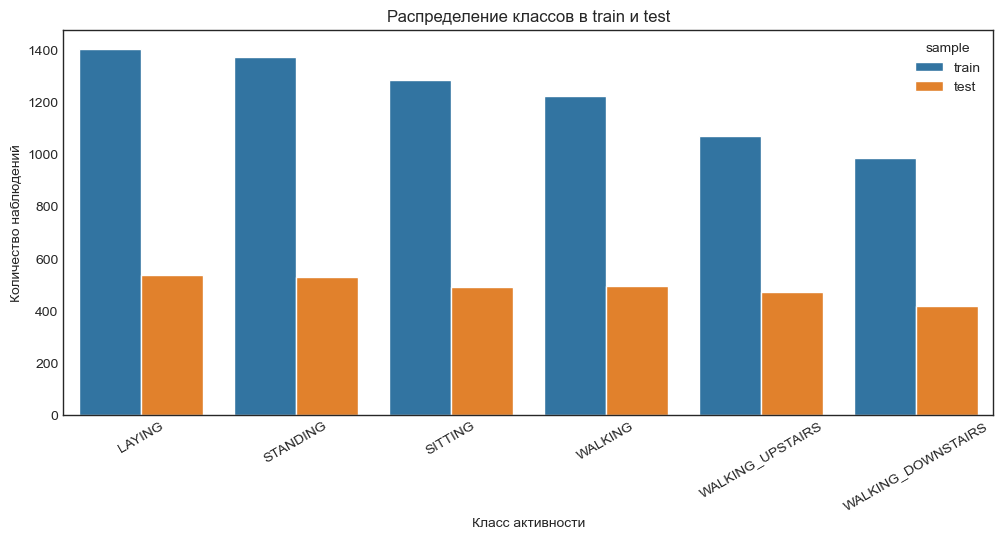

In [3]:
# читаем метки классов
activity_labels = pd.read_csv(
    os.path.join(datadir, "activity_labels.txt"),
    sep=r"\s+",
    header=None,
    names=["class_id", "activity"]
)

y_train = pd.read_csv(
    os.path.join(datadir, "train", "y_train.txt"),
    header=None,
    names=["class_id"]
)

y_test = pd.read_csv(
    os.path.join(datadir, "test", "y_test.txt"),
    header=None,
    names=["class_id"]
)

# добавляем названия активностей
y_train = y_train.merge(activity_labels, on="class_id")
y_test = y_test.merge(activity_labels, on="class_id")

train_counts = y_train["activity"].value_counts().reset_index()
train_counts.columns = ["activity", "count"]
train_counts["sample"] = "train"

test_counts = y_test["activity"].value_counts().reset_index()
test_counts.columns = ["activity", "count"]
test_counts["sample"] = "test"

class_dist = pd.concat([train_counts, test_counts])

plt.figure(figsize=(12, 5))
sns.barplot(data=class_dist, x="activity", y="count", hue="sample")
plt.xticks(rotation=30)
plt.title("Распределение классов в train и test")
plt.xlabel("Класс активности")
plt.ylabel("Количество наблюдений")
plt.show()

In [11]:
datadir = "UCI HAR Dataset"

X_train = pd.read_csv(
    os.path.join(datadir, "train", "X_train.txt"),
    sep=r"\s+",
    header=None
)

#print(X_train.head())
#print(X_train.shape)

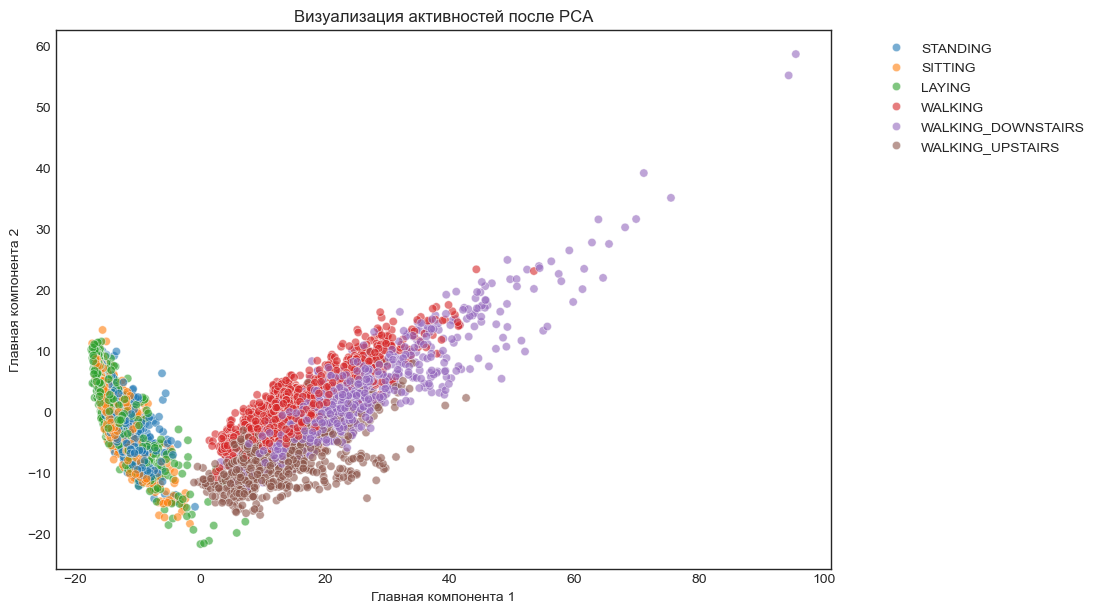

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled = StandardScaler().fit_transform(X_train)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["activity"] = y_train["activity"]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="activity", alpha=0.6)
plt.title("Визуализация активностей после PCA")
plt.xlabel("Главная компонента 1")
plt.ylabel("Главная компонента 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()